# Why is lesion T1 pulled towards white matter? — controlled experiments (CALIPR, synthetic phantom)

**Question (task 1).** On the static phantom both the LLR reference and CALIPR V1 bias lesion
T1 towards the surrounding white matter **beyond partial volume** (short-T1 lesions roughly
+9 to +15 % vs `ideal`, long-T1 lesions −6 to −8 %), and LLR's block size hardly changes it,
so part of the cause is probably shared. This notebook separates the candidate causes with
controlled experiments on the coronal plane, run for **CALIPR V1 only** (LLR is developed
locally; its numbers from `RECON_COMPARISON.md` are context only).

**Candidate causes and the experiment that isolates each**

| cause | how it could pull lesions towards WM | isolated by |
|---|---|---|
| pipeline (phases, PSIR combination, echo average, grid fit, evaluation) | systematic error outside the reconstruction | fully sampled, noise-free, true-map, unregularised control (section 4) |
| noise | noise-driven fit bias; the regulariser behaves differently at low SNR | noisy vs noise-free phantom (identical seed and phases) |
| 2 soft-SENSE map sets | twice the unknowns (under-determined at R ≈ 6 with 8 coils); set 1 can absorb signal | ENLIVE 2 vs 1 map set |
| coil-map estimation | ENLIVE maps estimated from the same undersampled data | ENLIVE 1 set vs the phantom's true maps |
| regularisation | wavelet shrinkage of the small, T1-carrying coefficients $c_2, c_3$ smooths them towards the neighbourhood | default λ vs λ → 0 (converged CG), plus a λ dose-response |
| undersampling | too little encoding to resolve the lesion; **the same pattern at every TI**, so what is lost is lost identically at every TI | what remains at λ → 0; per-TI SENSE with λ → 0 as the method-neutral floor |

Each row of the experiment ladder removes one cause relative to the previous row, so the
difference between consecutive rows is that cause's contribution (a sequential decomposition:
interactions are attributed to the step where they disappear).

All data are the synthetic phantom (`synth/phantom.py`); nothing here uses real subject data.
Reconstructions are run by `synth/run_bias_experiments.py` (cached outside the repo), so this
notebook only loads, evaluates and plots; it recomputes a condition only if its cache is missing.

## 1. Environment

In [1]:
import os, sys, json, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BART_PATH = os.environ.get('BART_TOOLBOX_PATH', '/Users/jackewins/bart/')
os.environ['BART_TOOLBOX_PATH'] = BART_PATH
sys.path.append(os.path.join(BART_PATH, 'python'))
REPO_DIR = Path(os.environ.get('QT1_REPO_DIR', Path.cwd()))
sys.path.insert(0, str(REPO_DIR / 'synth'))
import pipeline_utils as pu
import calipr as cal
import bias_diagnostics as bd
import run_bias_experiments as rbe
import phantom as ph

%matplotlib inline
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 72

## 2. Configuration

`PHANTOM_DIR` is the standard static phantom, `PHANTOM_NF_DIR` the same phantom generated with
`--noise 0` (same seed: the per-TI phase offsets and everything else are identical, only the
noise is absent). `CACHE` holds the runs of `run_bias_experiments.py`.

Conditions are named `<data>:<maps>:<method>:<reg>` (see the script's docstring). CALIPR is
V1 exactly (`pics -e -S -R W:7:0:0.005 -i 80 -U`, K = 3 dictionary basis, per-TI global phase
demodulation).

In [2]:
PHANTOM_DIR    = Path(os.environ.get('QT1_PHANTOM_DIR', Path.home() / 'work' / 'phantom'))
PHANTOM_NF_DIR = Path(os.environ.get('QT1_PHANTOM_NF_DIR', Path.home() / 'work' / 'phantom_nf'))
CACHE          = Path(os.environ.get('QT1_BIAS_CACHE', Path.home() / 'work' / 'bias'))
PLANE = 'COR'

LADDER = [  # (label, condition): each step removes one candidate cause
    ('0  noisy, ENLIVE 2 sets, λ=0.005', 'noisy:E2:CAL:def'),
    ('A1 noise-free, ENLIVE 2 sets',     'nf:E2:CAL:def'),
    ('A2 noise-free, ENLIVE 1 set',      'nf:E1:CAL:def'),
    ('A3 noise-free, true maps',         'nf:true:CAL:def'),
    ('A4 noise-free, true maps, λ→0',    'nf:true:CAL:zero'),
]
EXTRA = [
    ('A4 λ→0, 300 CG iterations',        'nf:true:CAL:zero300'),
    ('B1 true maps, λ=0.0005',           'nf:true:CAL:lam0.0005'),
    ('B1 true maps, λ=0.00005',          'nf:true:CAL:lam5e-05'),
    ('S  per-TI SENSE, λ→0 (no TI model)', 'nf:true:LLR:zero'),
    ('C1 ENLIVE 1 set, λ→0',             'nf:E1:CAL:zero'),
    ('C2 ENLIVE 2 sets, λ→0 (CG breaks down)', 'nf:E2:CAL:zero'),
]
os.environ['QT1_PHANTOM_DIR'], os.environ['QT1_PHANTOM_NF_DIR'] = str(PHANTOM_DIR), str(PHANTOM_NF_DIR)
scans = ph.load_scans(PHANTOM_DIR)[PLANE]
TI = np.array([s['info']['TI_s'] for s in scans]); TR = np.array([s['info']['TR_s'] for s in scans])
truth = dict(np.load(PHANTOM_DIR / f'truth_{PLANE}.npz'))
MASK = truth['label'] >= 3
sp = pu.spacing_of(scans[-1]['info']); ASP = sp[0] / sp[1]
print('TI (ms)', np.round(1000 * TI, 2), '| TR (s)', TR, '| voxel (mm)', np.round(sp, 3))

TI (ms) [ 30.75 150.   400.   800.  ] | TR (s) [1.225 1.35  1.6   2.   ] | voxel (mm) [1.786 1.8   5.   ]


## 3. The sampling pattern is identical at every TI

The phantom uses the real protocol's sampling coordinates. Within a plane, all four TIs (and
both echo groups) sample **exactly the same** phase-encode positions (the only exception is
axial TI31). Sampling is variable density: local undersampling R ≈ 2–3 near the k-space centre
rising to ≈ 8–10 at the edge.

Why this matters for any TI-coupled model (LLR or subspace): with one pattern for all TIs, the
aliasing at a voxel is the same superposition of other voxels at every TI, so the aliased signal
has a perfectly valid IR curve. A temporal model cannot tell it from true signal; only coil
encoding and the spatial regulariser can. It also means that whatever k-space content the
reconstruction fails to recover is missing identically at every TI.

AX TI31: 0/961 shared with TI800  TI150: 775/775 shared with TI800  TI400: 775/775 shared with TI800  TI800: 775/775 shared with TI800
COR TI31: 713/713 shared with TI800  TI150: 713/713 shared with TI800  TI400: 713/713 shared with TI800  TI800: 713/713 shared with TI800
SAG TI31: 651/651 shared with TI800  TI150: 651/651 shared with TI800  TI400: 651/651 shared with TI800  TI800: 651/651 shared with TI800


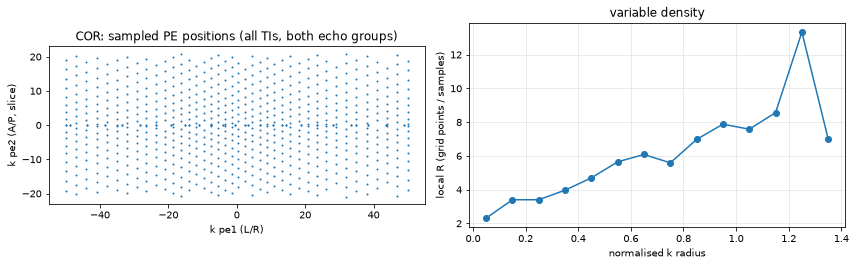

In [3]:
spec = ph.load_spec(); by = {}
for s in spec['scans']:
    by.setdefault(s['plane'], []).append(s)
for p, sl in by.items():
    sl.sort(key=lambda s: s['TI_s']); m = sl[-1]['matrix']
    pts = [set(map(tuple, np.round(np.stack([c[0, :, 0] * m[1], c[1, :, 0] * m[2]], 1), 2)))
           for c in [np.load(ph.HERE / 'acq_spec' / s['coord_file']) for s in sl]]
    print(p, '  '.join(f"{s['name'].split('_')[1]}: {len(q & pts[-1])}/{len(q)} shared with TI800" for s, q in zip(sl, pts)))

c = np.load(ph.HERE / 'acq_spec' / [s for s in by[PLANE] if s['name'].endswith('TI800')][0]['coord_file'])
m = scans[-1]['info']['matrix']; k1, k2 = c[0, :, 0] * m[1], c[1, :, 0] * m[2]
r = np.sqrt((k1 / (m[1] / 2)) ** 2 + (k2 / (m[2] / 2)) ** 2)
g1, g2 = np.meshgrid(np.arange(-m[1] // 2, m[1] // 2), np.arange(-m[2] // 2, m[2] // 2), indexing='ij')
rg = np.sqrt((g1 / (m[1] / 2)) ** 2 + (g2 / (m[2] / 2)) ** 2)
edges = np.linspace(0, 1.4, 15); h, _ = np.histogram(r, edges); hg, _ = np.histogram(rg, edges)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(k1, k2, '.', ms=2); ax[0].set_xlabel('k pe1 (L/R)'); ax[0].set_ylabel('k pe2 (A/P, slice)')
ax[0].set_title(f'{PLANE}: sampled PE positions (all TIs, both echo groups)'); ax[0].set_aspect(1)
ax[1].plot(0.5 * (edges[1:] + edges[:-1]), hg / np.maximum(h, 1), 'o-')
ax[1].set_xlabel('normalised k radius'); ax[1].set_ylabel('local R (grid points / samples)')
ax[1].set_title('variable density'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Evaluation checks before any reconstruction

**4a. The evaluation masks are off-centre (phantom truth issue, shared code — reported, not
changed here).** `truth['lesion_frac_by_id']` (like `lesion_fraction`, `T1_ms_pv` and `sens`)
is a block mean of the fine simulation grid, and those blocks are centred 0.25 voxel (in-plane)
and 0.375 voxel (through-plane, ≈ 1.9 mm) away from the reconstruction voxels. The masks used
by `evaluate_t1` therefore sit towards one edge of each lesion. The comparison stays fair
(ideal and estimate always use the same voxels), but the voxels include more partial volume,
which changes the magnitude of the numbers. Below, a correctly centred fraction is computed
(blocks centred on the reconstruction voxels) and every result is reported with **both**
masks.

**4b. Fully sampled control.** Same phantom, but every k-space point of the reconstruction
matrix sampled, noise-free, the true coil maps, no regularisation. Then SENSE has a closed form
(no solver, no iteration count): $x = \sum_c S_c^* \,\mathrm{trunc}(m\,e^{i\phi}S_c) / \sum_c |S_c|^2$.
Everything downstream (per-TI phase, `combine_maps`, echo average, `fit_t1_grid`,
`evaluate_t1`) is the real pipeline. A second variant truncates k-space at the pattern's actual
pe2 extent (|k₂| ≤ 20.92 instead of 22), to check whether the slightly smaller encoded extent
matters.

In [4]:
f = CACHE / 'lesion_frac_centred_COR.npz'
if not f.exists():
    info = scans[-1]['info']; fac = ph.FACTOR
    X, Y, Z = ph.grid_coords(info['matrix'], info['fov_mm'], info['geom'], fac)
    spf = [fv / (n * k) for fv, n, k in zip(info['fov_mm'], info['matrix'], fac)]
    xyz = [X, Y, Z]
    for j, a in enumerate(info['geom']):
        xyz[ph.AXIS[a]] = xyz[ph.AXIS[a]] - (fac[j] - 1) / 2 * spf[j]       # centre each block
    _, _, _, les = ph.tissue_maps(*xyz, 0)
    np.savez(f, frac=np.stack([ph.block_mean((les == i + 1).astype(np.float32), fac) for i in range(len(ph.LESIONS))]))
truth_c = dict(truth, lesion_frac_by_id=np.load(f)['frac'])

def centroid(v):
    idx = np.indices(v.shape).reshape(3, -1); w = v.ravel(); return (idx * w).sum(1) / w.sum()
info = scans[-1]['info']
print(f"{'lesion':8s} {'analytic centre (vox)':>24s} {'stored-frac centroid':>24s} {'centred-frac centroid':>24s}  peak PV stored / centred")
for i, (l, (lr, ap, si), d) in enumerate(ph.LESIONS):
    xyz = {'X': si, 'Y': lr, 'Z': ap}
    cen = [xyz[a] / sp[j] + info['matrix'][j] // 2 for j, a in enumerate(info['geom'])]
    print(f"L{i+1} {d:2d}mm  {str(np.round(cen, 2)):>24s} {str(np.round(centroid(truth['lesion_frac_by_id'][i]), 2)):>24s} "
          f"{str(np.round(centroid(truth_c['lesion_frac_by_id'][i]), 2)):>24s}  {truth['lesion_frac_by_id'][i].max():.2f} / {truth_c['lesion_frac_by_id'][i].max():.2f}")

lesion      analytic centre (vox)     stored-frac centroid    centred-frac centroid  peak PV stored / centred
L1 10mm       [75.6  33.33 26.  ]      [75.34 33.11 25.59]      [75.59 33.35 26.  ]  1.00 / 1.00
L2  6mm       [75.6  33.33 19.  ]      [75.37 33.06 18.65]      [75.62 33.3  19.  ]  0.75 / 1.00
L3  4mm          [64.4 30.  29. ]      [64.2  29.71 28.74]      [64.38 30.   29.  ]  0.50 / 0.75
L4  2mm          [64.4 30.  14. ]      [64.   29.75 14.  ]         [64.5 30.  14. ]  0.19 / 0.25
L5 10mm       [75.6  66.67 26.  ]      [75.34 66.39 25.59]      [75.59 66.65 26.  ]  1.00 / 1.00
L6  6mm       [75.6  66.67 19.  ]      [75.37 66.43 18.65]      [75.62 66.7  19.  ]  0.75 / 1.00


L7  4mm          [64.4 70.  29. ]      [64.2  69.71 28.74]      [64.38 70.   29.  ]  0.50 / 0.75
L8  2mm          [64.4 70.  14. ]      [64.   69.75 14.  ]         [64.5 70.  14. ]  0.19 / 0.25


In [5]:
def fs_control(tag, kmax):
    f = CACHE / f'fs_control_{tag}_COR.npz'
    if not f.exists():
        r = bd.fully_sampled_control(PHANTOM_DIR, PLANE, kmax=kmax, verbose=False)
        S = np.mean([np.real(pu.combine_maps(x)) for x in r['img']], axis=0)
        T1, M0, R2 = pu.fit_t1_grid(S, TI, TR, MASK)
        np.savez(f, signed=S.astype(np.float32), T1_s=T1, R2=R2, img0=r['img'][0], img1=r['img'][1])
    return dict(np.load(f))

FS = {'FS': fs_control('FS', None), 'FS |k2|<=20.92': fs_control('FS_k2', (None, None, 20.921))}
ideal_rows = pu.evaluate_t1(truth['T1_ideal_ms'] / 1000, truth)
ideal_rows_c = pu.evaluate_t1(truth['T1_ideal_ms'] / 1000, truth_c)
rows_fs = {k: (pu.evaluate_t1(v['T1_s'], truth), pu.evaluate_t1(v['T1_s'], truth_c)) for k, v in FS.items()}
print(f"{'region':18s} {'true':>7s} | {'ideal':>7s} " + ' '.join(f'{k:>16s}' for k in FS) +
      f" | {'ideal (centred)':>15s} " + ' '.join(f'{k:>16s}' for k in FS))
for i, r in enumerate(ideal_rows):
    print(f"{r['region']:18s} {r['true_ms']:7.1f} | {r['ideal_ms']:7.1f} "
          + ' '.join(f"{rows_fs[k][0][i]['bias_vs_ideal_pct']:+15.1f}%" for k in FS)
          + f" | {ideal_rows_c[i].get('ideal_ms', np.nan):15.1f} "
          + ' '.join(f"{rows_fs[k][1][i].get('bias_vs_ideal_pct', np.nan):+15.1f}%" for k in FS))

region                true |   ideal               FS   FS |k2|<=20.92 | ideal (centred)               FS   FS |k2|<=20.92
WM                   259.8 |   259.8            +0.1%            +0.1% |           259.8            +0.1%            +0.1%
GM                   309.2 |   308.8            -0.1%            -0.4% |           308.8            -0.1%            -0.4%
CSF                 3543.3 |  3862.6            +0.5%            +3.4% |          3862.6            +0.5%            +3.4%
lesion 1 (10 mm)     338.0 |   313.7            -0.1%            -0.5% |           322.2            -0.2%            -1.2%
lesion 2 (6 mm)      338.0 |   304.2            -0.0%            +0.9% |           317.4            -0.0%            +1.6%
lesion 3 (4 mm)      338.0 |   293.1            -0.0%            -1.4% |           315.8            -0.3%            -2.9%
lesion 4 (2 mm)      338.0 |   268.3            +0.3%            +1.1% |           267.2            +0.0%            +1.0%
lesion 5 (10 mm)

**Reading.** The fully sampled control reproduces `ideal` to within ±0.3 % in every region
and lesion (either mask): the pipeline itself (phase handling, PSIR combination, echo averaging,
fit, evaluation, and the 3 %-offset true coil maps) adds no measurable bias. Cutting k-space to
the pattern's real pe2 extent moves lesions by 1–3 % with mixed sign, not systematically
towards WM. So any bias beyond these levels below is created by the **reconstruction of
undersampled data** (undersampling, regularisation, coil maps, map sets, noise).

The table also shows how much the mask offset matters for the *ideal* itself: e.g. the 4 mm
lesions read 293 / 225 ms with the stored mask and 316 / 204 ms with the centred one.

## 5. The experiment ladder

Loads each condition from `CACHE` (running it with `run_bias_experiments.run` if missing: about
5 min for a CALIPR condition on 4 cores, 20 min for the λ → 0, 300-iteration one). The table is
bias vs `ideal` in %, with the stored masks (the numbers comparable to earlier tables) and the
centred masks. The same `ideal` is used for noisy and noise-free data (identical object).

In [6]:
res = {}
for label, cond in LADDER + EXTRA:
    f = CACHE / f"{PLANE}_{cond.replace(':', '_')}.npz"
    if not f.exists():
        rbe.run(CACHE, cond)
    z = dict(np.load(f))
    res[cond] = dict(label=label, z=z, rows=pu.evaluate_t1(z['T1_s'], truth), rows_c=pu.evaluate_t1(z['T1_s'], truth_c))

def table(conds, key='rows'):
    names = [r['region'] for r in ideal_rows]
    print(f"{'condition':38s} " + ' '.join(f'{n.replace("lesion ", "L").replace(" mm)", ")"):>9s}' for n in names))
    for c in conds:
        rr = res[c][key]
        print(f"{res[c]['label']:38s} " + ' '.join(f"{r.get('bias_vs_ideal_pct', np.nan):+8.1f}%" for r in rr)
              + f"   [{float(res[c]['z']['seconds']) / 60:.1f} min]")

print('bias vs ideal (%), STORED lesion masks  (L1-4 long T1 338 ms, L5-8 short T1 182 ms; L4/L8 are 1-2 voxels)')
table([c for _, c in LADDER + EXTRA])
print('\nbias vs ideal (%), CENTRED lesion masks')
table([c for _, c in LADDER + EXTRA], 'rows_c')
print('\nT1 SD (ms) within WM / GM:  ' + '   '.join(f"{res[c]['label'][:2]}: {res[c]['rows'][0]['sd_ms']:.1f} / {res[c]['rows'][1]['sd_ms']:.1f}" for _, c in LADDER + EXTRA))

bias vs ideal (%), STORED lesion masks  (L1-4 long T1 338 ms, L5-8 short T1 182 ms; L4/L8 are 1-2 voxels)
condition                                     WM        GM       CSF   L1 (10)    L2 (6)    L3 (4)    L4 (2)   L5 (10)    L6 (6)    L7 (4)    L8 (2)
0  noisy, ENLIVE 2 sets, λ=0.005           -2.0%     -2.0%    -94.2%     -3.1%    -24.6%     -5.7%    +13.2%    +11.7%     +8.7%    +14.4%     +6.3%   [10.8 min]
A1 noise-free, ENLIVE 2 sets               -1.9%     -1.8%    -92.3%     -5.6%    -26.4%     -7.0%     +8.6%    +12.1%     +8.0%    +15.9%     +3.1%   [10.4 min]
A2 noise-free, ENLIVE 1 set                -0.2%     -0.3%    -87.6%     -6.1%     -6.5%     -6.8%     -6.2%    +10.4%     +6.0%     -5.4%    -12.2%   [10.2 min]
A3 noise-free, true maps                   +0.1%     +0.0%     -2.5%     -3.4%     -3.5%     -4.9%     -2.7%     +2.2%     +5.0%     +4.6%     +4.5%   [6.3 min]
A4 noise-free, true maps, λ→0              -0.0%     -0.6%    -62.3%     -2.8%     +3.9%     -0.9%

**Decomposition.** Each bar is the change in bias vs ideal (percentage points) from one step
of the ladder to the next — i.e. the contribution of the cause removed at that step. Lesions 1–3
and 5–7 (the 2 mm lesions are single voxels and are left out). Positive = towards longer T1.

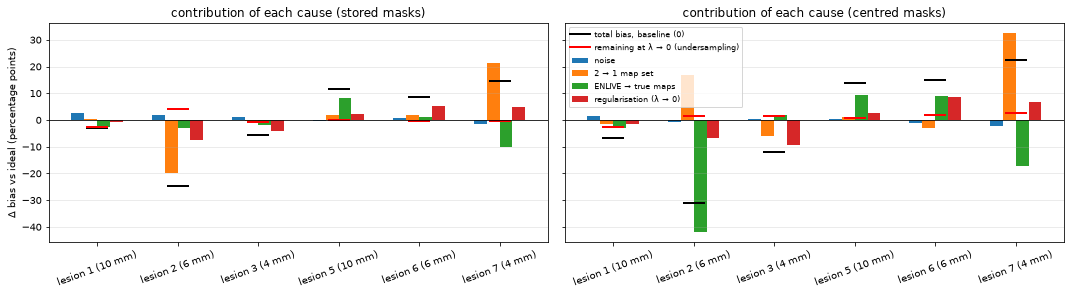

In [7]:
steps = [('noise', 0, 1), ('2 → 1 map set', 1, 2), ('ENLIVE → true maps', 2, 3),
         ('regularisation (λ → 0)', 3, 4)]
les = [3, 4, 5, 7, 8, 9]           # row indices: L1-3, L5-7
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), sharey=True)
for ax, key, ttl in ((axes[0], 'rows', 'stored masks'), (axes[1], 'rows_c', 'centred masks')):
    b = np.array([[res[c][key][i]['bias_vs_ideal_pct'] for i in les] for _, c in LADDER])   # (5, 6)
    w = 0.16; xx = np.arange(len(les))
    for s, (name, a, bb) in enumerate(steps):
        ax.bar(xx + (s - 1.5) * w, b[a] - b[bb], w, label=f'{name}')
    ax.plot(xx, b[0], 'k_', ms=22, mew=2, label='total bias, baseline (0)')
    ax.plot(xx, b[-1], 'r_', ms=22, mew=2, label='remaining at λ → 0 (undersampling)')
    ax.set_xticks(xx); ax.set_xticklabels([ideal_rows[i]['region'] for i in les], rotation=20)
    ax.axhline(0, color='k', lw=0.8); ax.grid(alpha=0.3, axis='y'); ax.set_title(f'contribution of each cause ({ttl})')
axes[0].set_ylabel('Δ bias vs ideal (percentage points)'); axes[1].legend(fontsize=8, loc='best')
plt.tight_layout(); plt.show()

## 6. Where the bias sits: lesion zooms

Each lesion at the slice of its peak (centred) partial-volume fraction, ±10 voxels: `ideal`,
then T1 for every step of the ladder. White contour: centred evaluation mask.

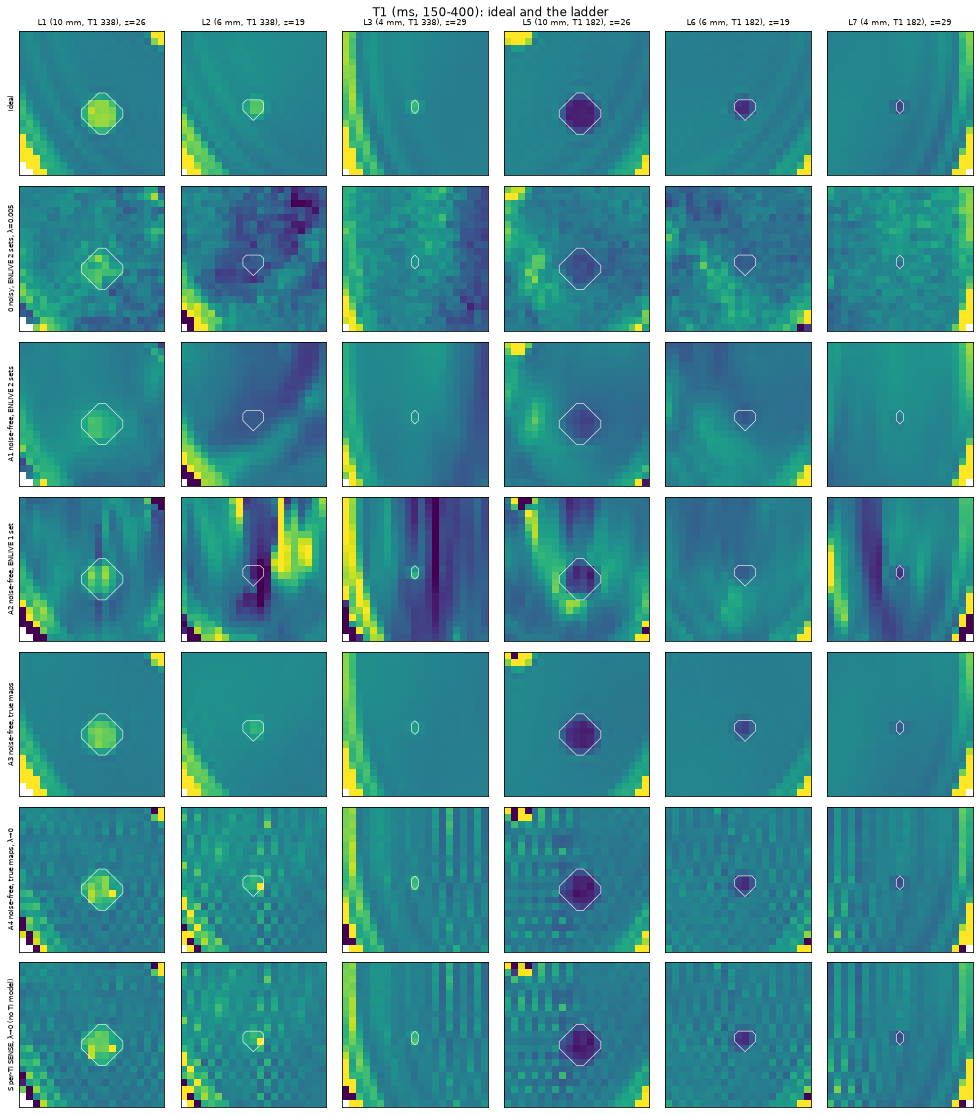

In [8]:
def lesion_zoom(conds, h=10):
    frc = truth_c['lesion_frac_by_id']; order = [0, 1, 2, 4, 5, 6]
    rows_ = [('ideal', truth['T1_ideal_ms'])] + [(res[c]['label'][:2].strip() + ' ' + res[c]['label'][3:], 1000 * res[c]['z']['T1_s']) for c in conds]
    fig, axes = plt.subplots(len(rows_), len(order), figsize=(2.3 * len(order), 2.25 * len(rows_)), squeeze=False)
    for j, i in enumerate(order):
        x0, y0, z0 = np.unravel_index(np.argmax(frc[i]), frc[i].shape)
        sl = (slice(max(x0 - h, 0), x0 + h + 1), slice(max(y0 - h, 0), y0 + h + 1), z0)
        for r, (name, vol) in enumerate(rows_):
            a = axes[r, j]
            a.imshow(vol[sl], cmap='viridis', vmin=150, vmax=400, aspect=ASP)
            a.contour(frc[i][sl] >= 0.5 * frc[i].max(), [0.5], colors='w', linewidths=0.6)
            a.set_xticks([]); a.set_yticks([])
            if j == 0: a.set_ylabel(name, fontsize=7)
            if r == 0: a.set_title(f'L{i+1} ({ph.LESIONS[i][2]} mm, T1 {pu.TRUE_LESION_T1[ph.LESIONS[i][0]]:.0f}), z={z0}', fontsize=8)
    plt.suptitle('T1 (ms, 150-400): ideal and the ladder'); plt.tight_layout(); plt.show()

lesion_zoom([c for _, c in LADDER] + ['nf:true:LLR:zero'])

## 7. Line profiles through the lesions

Profiles through the peak voxel of the 10 mm and 4 mm lesion pairs along the read (S/I), pe1
(L/R) and pe2 (A/P, 5 mm slice) directions. Top: T1. Bottom: the normalised signal
$S(TI150)/S(TI800)$, which carries most of the T1 contrast (WM ≈ −0.13, short-T1 lesion
≈ +0.14, long-T1 lesion ≈ −0.29 at full volume). A reconstruction that only loses resolution
would show wider, lower lesion bumps; one that distorts contrast would show a lower bump of
the same width.

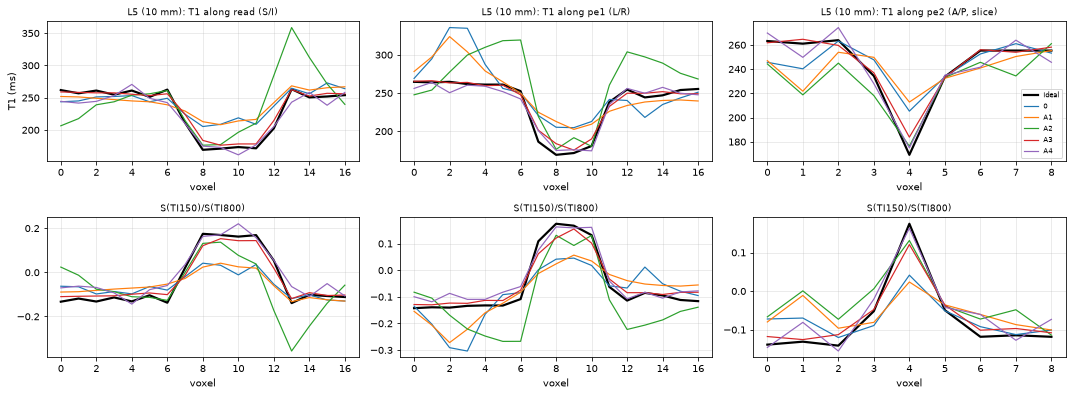

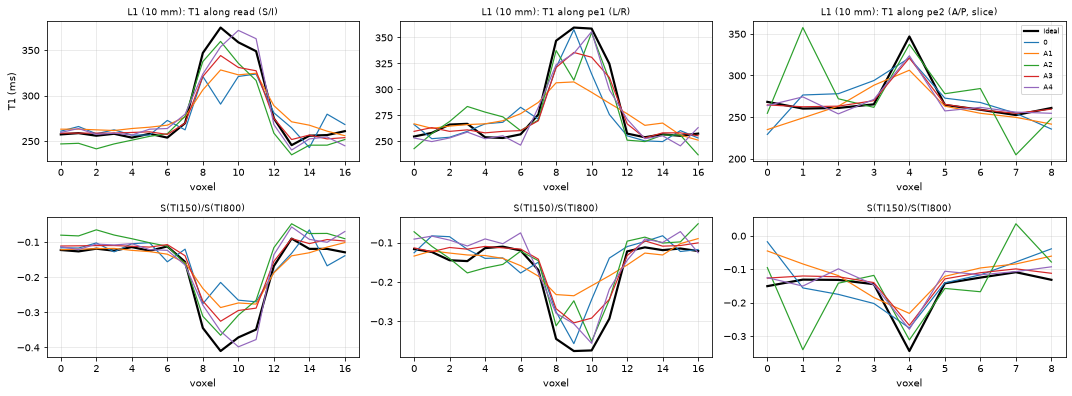

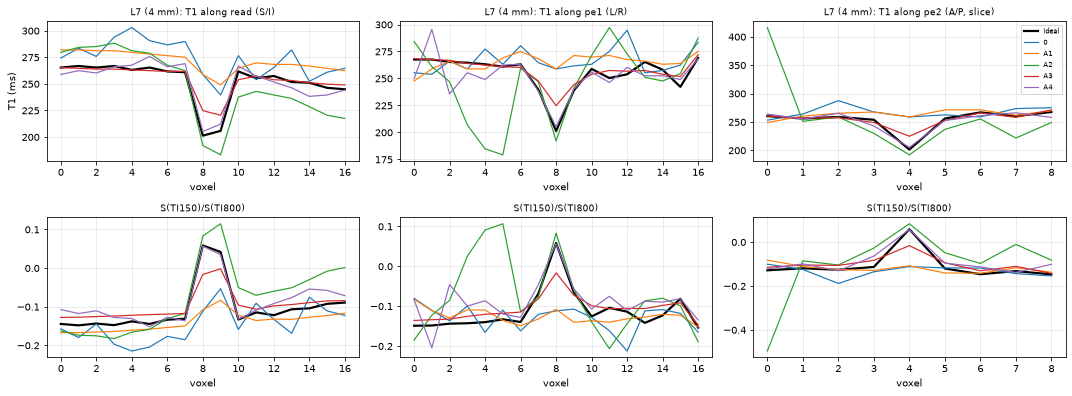

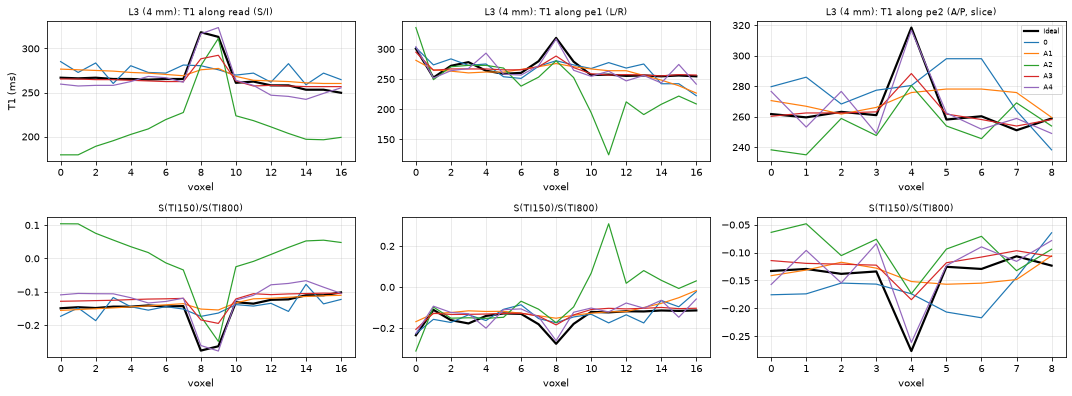

In [9]:
def profiles(i, conds, h=8):
    frc = truth_c['lesion_frac_by_id'][i]; x0, y0, z0 = np.unravel_index(np.argmax(frc), frc.shape)
    cuts = {'read (S/I)': (slice(x0 - h, x0 + h + 1), y0, z0), 'pe1 (L/R)': (x0, slice(y0 - h, y0 + h + 1), z0),
            'pe2 (A/P, slice)': (x0, y0, slice(max(z0 - 4, 0), z0 + 5))}
    src = [('ideal', truth['T1_ideal_ms'], truth['S_ideal'], 'k', 2.2)] + \
          [(res[c]['label'][:2].strip(), 1000 * res[c]['z']['T1_s'], res[c]['z']['signed'], None, 1.2) for c in conds]
    fig, axes = plt.subplots(2, 3, figsize=(15, 5.6))
    for j, (name, cut) in enumerate(cuts.items()):
        for lab, t1, S, col, lw in src:
            ratio = S[..., 1] / np.where(np.abs(S[..., -1]) > 0, S[..., -1], np.nan)
            axes[0, j].plot(t1[cut], color=col, lw=lw, label=lab); axes[1, j].plot(ratio[cut], color=col, lw=lw, label=lab)
        axes[0, j].set_title(f'L{i+1} ({ph.LESIONS[i][2]} mm): T1 along {name}', fontsize=9)
        axes[1, j].set_title('S(TI150)/S(TI800)', fontsize=9)
        for a in axes[:, j]: a.grid(alpha=0.3); a.set_xlabel('voxel')
    axes[0, 0].set_ylabel('T1 (ms)'); axes[0, 2].legend(fontsize=7)
    plt.tight_layout(); plt.show()

for i in (4, 0, 6, 2):          # L5, L1 (10 mm), L7, L3 (4 mm)
    profiles(i, [c for _, c in LADDER])

## 8. Is it extra partial volume? Curve-mixing fit

For each lesion, the mean normalised TI curve of the evaluation voxels (centred mask) in the
reconstruction is fitted as a mix of the ideal lesion curve and the ideal curve of the WM ring
around it: $s_{rec} = a\, s_{ideal,lesion} + (1-a)\, s_{ideal,WM}$. $a = 1$: nothing lost;
$a < 1$ with a **small residual**: the lesion is diluted with surrounding WM — exactly what extra
partial volume (a wider point-spread function) does, and a mechanism that is independent of TI.
A large residual means the curve is distorted in a TI-dependent way that mixing cannot
explain (e.g. contrast lost at some TIs only).

In [10]:
print(f"{'condition':38s} " + ' '.join(f'{"L"+str(i+1)+" a / res":>14s}' for i in (0, 1, 2, 4, 5, 6)))
mix = {}
for label, cond in [('FS control', None)] + LADDER + EXTRA:
    S = FS['FS']['signed'] if cond is None else res[cond]['z']['signed']
    out = []
    for i in (0, 1, 2, 4, 5, 6):
        core, ring = bd.lesion_masks(truth_c, i)
        out.append(bd.mixing_fit(S, truth['S_ideal'], core, ring))
    mix[cond] = out
    print(f"{label:38s} " + ' '.join(f"{o['a']:6.2f} / {o['rel_resid']:4.2f}" for o in out))

condition                                  L1 a / res     L2 a / res     L3 a / res     L5 a / res     L6 a / res     L7 a / res
FS control                               0.98 / 0.07   0.98 / 0.10   0.97 / 0.09   0.99 / 0.07   0.98 / 0.07   0.99 / 0.08
0  noisy, ENLIVE 2 sets, λ=0.005         0.65 / 0.15  -1.21 / 0.41   0.31 / 0.20   0.53 / 0.17   0.51 / 0.12   0.17 / 0.13


A1 noise-free, ENLIVE 2 sets             0.60 / 0.10  -1.13 / 0.35   0.31 / 0.14   0.54 / 0.12   0.48 / 0.14   0.08 / 0.13
A2 noise-free, ENLIVE 1 set              0.66 / 0.12  -2.57 / 0.33   0.63 / 0.15   0.54 / 0.13   0.39 / 0.11   1.29 / 0.31
A3 noise-free, true maps                 0.80 / 0.09   0.66 / 0.14   0.56 / 0.12   0.88 / 0.12   0.66 / 0.13   0.63 / 0.20


A4 noise-free, true maps, λ→0            0.84 / 0.10   0.85 / 0.14   1.06 / 0.10   0.96 / 0.10   0.92 / 0.09   0.90 / 0.12
A4 λ→0, 300 CG iterations                0.02 / 0.13   0.08 / 0.19  -0.14 / 0.28   0.97 / 0.10   0.97 / 0.10   0.80 / 0.20
B1 true maps, λ=0.0005                   0.85 / 0.10   0.87 / 0.12   0.92 / 0.11   0.96 / 0.10   0.88 / 0.10   0.88 / 0.14


B1 true maps, λ=0.00005                  0.84 / 0.10   0.92 / 0.12   1.00 / 0.10   0.97 / 0.10   0.89 / 0.09   0.92 / 0.12
S  per-TI SENSE, λ→0 (no TI model)       0.83 / 0.08   0.85 / 0.12   1.05 / 0.09   0.94 / 0.07   0.91 / 0.05   0.88 / 0.07


C1 ENLIVE 1 set, λ→0                     0.14 / 0.14  -1.33 / 0.24  -1.14 / 0.25  -0.08 / 0.11   0.72 / 0.11   6.25 / 0.94
C2 ENLIVE 2 sets, λ→0 (CG breaks down)  -0.82 / 0.18  -1.34 / 0.26  -0.65 / 0.20   0.76 / 0.10   0.54 / 0.13   0.36 / 0.17


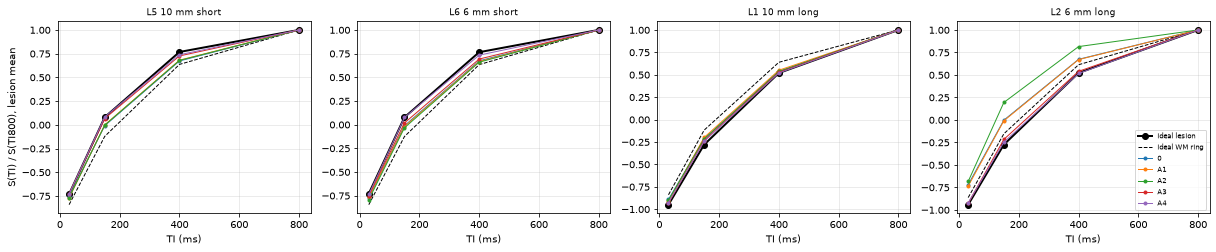

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, j, name in zip(axes, (3, 4, 0, 1), ('L5 10 mm short', 'L6 6 mm short', 'L1 10 mm long', 'L2 6 mm long')):
    m0 = mix['noisy:E2:CAL:def'][j]
    ax.plot(1000 * TI, m0['ideal_core'], 'k-o', lw=2, label='ideal lesion')
    ax.plot(1000 * TI, m0['ideal_ring'], 'k--', lw=1, label='ideal WM ring')
    for _, c in LADDER:
        ax.plot(1000 * TI, mix[c][j]['rec_core'], '-o', ms=3, lw=1, label=res[c]['label'][:2].strip())
    ax.set_title(name, fontsize=9); ax.set_xlabel('TI (ms)'); ax.grid(alpha=0.3)
axes[0].set_ylabel('S(TI) / S(TI800), lesion mean'); axes[-1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 9. How much blur would explain it?

The ideal signal blurred with a Gaussian point-spread function (FWHM in voxels along read, pe1,
pe2) and fitted: the lesion bias that pure extra partial volume of a given width causes. WM is
unaffected by blur (its T1 varies smoothly).

In [12]:
fws = [(0, 0, 1.0), (0, 0, 1.5), (1, 1, 0), (2, 2, 0), (1, 1, 1.0), (1.5, 1.5, 1.0), (2, 2, 1.0), (3, 3, 1.0)]
print(f"{'blur FWHM (read, pe1, pe2) vox':32s} " + ' '.join(f'{"L"+str(i+1):>7s}' for i in (0, 1, 2, 4, 5, 6)) + '   (centred masks)')
for fw in fws:
    t1, _, _ = pu.fit_t1_grid(bd.blur_ideal(truth['S_ideal'], fw), TI, TR, MASK)
    rr = pu.evaluate_t1(t1, truth_c)
    print(f"{str(fw):32s} " + ' '.join(f"{rr[i]['bias_vs_ideal_pct']:+6.1f}%" for i in (3, 4, 5, 7, 8, 9)))

blur FWHM (read, pe1, pe2) vox        L1      L2      L3      L5      L6      L7   (centred masks)


(0, 0, 1.0)                        -1.9%   -1.7%   -2.3%   +1.8%   +2.9%   +2.5%


(0, 0, 1.5)                        -6.0%   -5.3%   -7.4%   +6.4%  +10.0%   +8.8%


(1, 1, 0)                          -0.9%   -1.2%   -2.5%   +0.9%   +1.9%   +3.2%


(2, 2, 0)                          -4.3%   -5.6%  -10.3%   +4.6%   +9.7%  +15.1%


(1, 1, 1.0)                        -2.6%   -2.7%   -4.5%   +2.5%   +4.5%   +5.4%


(1.5, 1.5, 1.0)                    -4.3%   -4.9%   -8.7%   +4.5%   +8.6%  +12.1%


(2, 2, 1.0)                        -5.6%   -6.7%  -11.3%   +6.1%  +11.8%  +16.2%


(3, 3, 1.0)                        -8.4%   -9.3%  -14.1%   +9.6%  +17.3%  +21.2%


## 10. Regularisation dose-response and convergence

Bias vs λ for CALIPR on noise-free data with the true maps (λ = 0.005 default, 0.0005, 0.00005,
and λ → 0), and the λ → 0 solution after 100 vs 300 CG iterations (a change between them means
the unregularised problem is not converged and early stopping is still acting as a
regulariser).

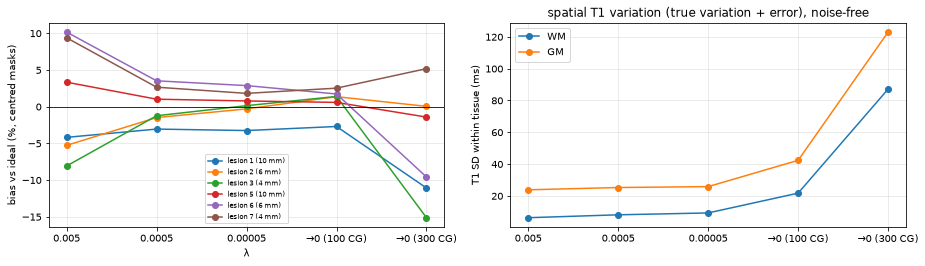

λ→0: relative change of the signed signal in brain, 100 → 300 CG iterations: 0.5873


In [13]:
dose = [('0.005', 'nf:true:CAL:def'), ('0.0005', 'nf:true:CAL:lam0.0005'), ('0.00005', 'nf:true:CAL:lam5e-05'),
        ('→0 (100 CG)', 'nf:true:CAL:zero'), ('→0 (300 CG)', 'nf:true:CAL:zero300')]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for i in (3, 4, 5, 7, 8, 9):
    ax[0].plot(range(len(dose)), [res[c]['rows_c'][i]['bias_vs_ideal_pct'] for _, c in dose], 'o-', label=ideal_rows[i]['region'])
ax[0].set_xticks(range(len(dose))); ax[0].set_xticklabels([d for d, _ in dose]); ax[0].set_xlabel('λ')
ax[0].set_ylabel('bias vs ideal (%, centred masks)'); ax[0].axhline(0, color='k', lw=0.8); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=7)
ax[1].plot(range(len(dose)), [res[c]['rows'][0]['sd_ms'] for _, c in dose], 'o-', label='WM')
ax[1].plot(range(len(dose)), [res[c]['rows'][1]['sd_ms'] for _, c in dose], 'o-', label='GM')
ax[1].set_xticks(range(len(dose))); ax[1].set_xticklabels([d for d, _ in dose]); ax[1].set_ylabel('T1 SD within tissue (ms)')
ax[1].set_title('spatial T1 variation (true variation + error), noise-free'); ax[1].grid(alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()
a, b = res['nf:true:CAL:zero']['z']['signed'], res['nf:true:CAL:zero300']['z']['signed']
br = truth['label'] >= 4
print(f'λ→0: relative change of the signed signal in brain, 100 → 300 CG iterations: '
      f'{np.linalg.norm(a[br] - b[br]) / np.linalg.norm(b[br]):.4f}')

## 11. Where it comes from: the self-calibrated coil maps

The ladder points at the coil maps (the step ENLIVE → true maps), so two direct checks:

1. **Do the ENLIVE maps match the true sensitivities?** Per voxel, the ENLIVE map-set-0 vector
   (8 coils) is projected onto the true map vector with a free complex scale $g$ (so an
   arbitrary smooth intensity/phase factor between image and maps is allowed); the residual is
   what $g$ cannot explain. Also: does anything in the maps look like the lesion (core vs WM
   ring), and how much energy is in map set 1?
2. **Can the reconstruction explain the measured data?** The TI800 image of each run (echo 0,
   noise-free data) is pushed back through the forward model with its own maps and compared
   with the measured k-space. With correct maps this residual is small (model error of the
   fine-grid simulation only).

In [14]:
t0_ = truth; St = pu.unit_rss(t0_['sens'])[..., 0]
fr = truth_c['lesion_frac_by_id']
def core_ring(i):
    core, ring = bd.lesion_masks(truth_c, i); return core, ring
print(f"{'maps':5s} {'lesion':7s} {'|g| core/ring':>15s} {'unexplained map fraction core/ring':>36s} {'map set 1 RSS core/ring':>26s}")
for tag in ('E2', 'E1'):
    S = np.load(CACHE / f'sens_{PLANE}_nf_{tag}_e0.npz')['s']
    g = np.sum(np.conj(St) * S[..., 0], -1) / np.maximum(np.sum(np.abs(St) ** 2, -1), 1e-12)
    resid = np.sqrt(np.sum(np.abs(S[..., 0] - g[..., None] * St) ** 2, -1))
    rss1 = np.sqrt(np.sum(np.abs(S[..., 1]) ** 2, -1)) if S.shape[-1] > 1 else np.zeros(g.shape)
    for i in (0, 4, 6):
        core, ring = core_ring(i)
        print(f"{tag:5s} L{i+1:<6d} {np.abs(g[core]).mean():7.3f}/{np.abs(g[ring]).mean():.3f} {resid[core].mean():27.3f}/{resid[ring].mean():.3f} "
              f"{rss1[core].mean():19.3f}/{rss1[ring].mean():.3f}")

sc_nf = ph.load_scans(PHANTOM_NF_DIR)[PLANE]; t_, d_ = pu.load_echo(sc_nf[-1]['stem'], 0)
def kresid(cond, maps):
    x = res[cond]['z']['img0'][..., -1]                                   # TI800, (X,Y,Z,M)
    S = pu.unit_rss(truth['sens']) if maps == 'true' else np.load(CACHE / f'sens_{PLANE}_nf_{maps}_e0.npz')['s']
    S = S if S.ndim == 5 else S[..., None]
    k = pu.bart(1, 'nufft', t_, np.sum(x[:, :, :, None, :] * S, -1).astype(np.complex64)).reshape(d_.shape)
    return np.linalg.norm(k - d_) / np.linalg.norm(d_)
print('\nrelative k-space residual at TI800, echo 0, noise-free data:')
for cond, maps in (('nf:true:CAL:zero', 'true'), ('nf:true:CAL:def', 'true'), ('nf:E1:CAL:zero', 'E1'),
                   ('nf:E1:CAL:def', 'E1'), ('nf:E2:CAL:def', 'E2'), ('nf:E2:CAL:zero', 'E2')):
    print(f"  {res[cond]['label']:42s} {kresid(cond, maps):.4f}")

maps  lesion    |g| core/ring   unexplained map fraction core/ring    map set 1 RSS core/ring


E2    L1        0.807/0.806                       0.302/0.306               0.508/0.507
E2    L5        0.771/0.771                       0.458/0.458               0.441/0.442
E2    L7        0.688/0.687                       0.560/0.561               0.461/0.461


E1    L1        0.839/0.839                       0.545/0.543               0.000/0.000
E1    L5        0.825/0.827                       0.566/0.563               0.000/0.000
E1    L7        0.856/0.857                       0.518/0.516               0.000/0.000

relative k-space residual at TI800, echo 0, noise-free data:


  A4 noise-free, true maps, λ→0              0.0453


  A3 noise-free, true maps                   0.0258


  C1 ENLIVE 1 set, λ→0                       0.3109


  A2 noise-free, ENLIVE 1 set                0.3114


  A1 noise-free, ENLIVE 2 sets               0.0420


  C2 ENLIVE 2 sets, λ→0 (CG breaks down)     6.0182


**Reading.** The ENLIVE maps contain nothing lesion-shaped (core and ring are identical), but
they are far from the true sensitivities: after allowing a free complex scale per voxel,
30–57 % of the map vector is left unexplained, for one and for two map sets, and map set 1
carries ~45–50 % RSS everywhere (as on the real data). With **one** ENLIVE set, 31 % of the
noise-free k-space cannot be explained, with or without regularisation (true maps: 2.6–4.5 %,
which is the simulation's own model error). **Two** sets bring the residual down to 4.2 % —
not by being right, but by doubling the unknowns (8800 complex unknowns vs 5888 samples per
readout position and TI: under-determined), so the data are fitted by a different split of the
signal between the two sets. At the 10 mm short-T1 lesion (echo 0, A1) the TI150 contrast is
indeed split: set 0 keeps −0.036 (true +0.10) and set 1 holds +0.056 against −0.014 in the WM
ring, and the phase-referenced sum loses most of it. The unregularised 2-set run (C2) is not a
valid solution: its data residual is 6× the data norm, i.e. CG broke down on the singular
problem, so its T1 values are ignored.

## 12. Conclusions

**Answer.** The pull of lesion T1 towards WM is **not** partial volume from lost resolution and
not a property of the subspace (or LLR) model itself. On this phantom it comes mainly from the
**self-calibrated coil maps**, with a smaller contribution from the **regulariser**; noise and
undersampling as such contribute essentially nothing.

| step removed (sequential) | short-T1 lesions 10/6/4 mm | long-T1 lesions 10/6/4 mm | evidence |
|---|---|---|---|
| pipeline (phases, PSIR, echo average, fit) | ±0.3 % | ±0.3 % | fully sampled control = ideal |
| noise (0 → A1) | ≤ 1.5 pts | ≤ 2.5 pts | noisy ≈ noise-free |
| ENLIVE 2 sets → true maps (A1 → A3) | 9.9 / 3.0 / 11.3 pts | 2.2 / 22.9 / 2.1 pts | biggest step; map errors 30–57 %, data residual 31 % with 1 set |
| regularisation λ = 0.005 → 0 (A3 → A4) | 2.1 / 5.4 / 4.8 pts | 0.6 / 7.4 / 4.0 pts | gone already at λ = 0.0005 (noise-free) |
| undersampling itself (A4) | 0.1 / −0.4 / −0.2 % | −2.8 / +3.9 / −0.9 % | per-TI SENSE without any TI model gives the same |

(stored masks; with centred masks the ENLIVE step is 10.5 / 5.8 / 15.3 and the regulariser
step 2.7 / 8.5 / 6.9 points for the short-T1 lesions — the regulariser matters more for the
4–6 mm lesions than the stored masks suggest.)

**Mechanism.**
1. *The shape of the error is contrast loss, not blur.* In the line profiles the lesion bump of
   $S(TI150)/S(TI800)$ keeps its width in all three directions but loses ~¾ of its height with
   ENLIVE maps; with the true maps the height returns. The mixing fit agrees: the reconstructed
   lesion curve is a mix of ~50 % lesion and ~50 % surrounding-WM curve with a small residual,
   i.e. the lesion looks diluted with WM — which is why it reads as "beyond partial volume".
   Pure Gaussian blur would need ≈ 2–3 voxels FWHM in-plane to produce the same bias, which the
   images do not show.
2. *Why wrong maps dilute the lesion rather than add noise.* With inaccurate maps the unfolding
   of the ≈ 6-fold aliasing is imperfect, so some of a voxel's signal is assigned to its alias
   partners and some of theirs to it. Because **every TI uses the same sampling pattern**, the
   exchanged signal is a genuine IR curve of other tissue (mostly WM, the most abundant tissue
   at the alias positions), identical in form at every TI — so neither a temporal subspace nor a
   low-rank model can tell it apart from true signal. The regulariser then removes the obvious
   artefacts (unregularised reconstructions with ENLIVE maps are much worse: C1), leaving a
   clean-looking image whose small, lesion-specific contrast is diluted. *This leakage step is
   inferred from the evidence above (width preserved, WM-like mixing, maps unable to explain
   the data), not imaged directly.*
3. *Two map sets hide the map error rather than fix it*: they restore data consistency by
   doubling the unknowns, and the lesion contrast ends up split between the sets and partly lost
   in the phase-referenced combination. With one ENLIVE set the error shows up openly (band-like
   T1 artefacts, WM T1 SD 57 ms vs 6 ms with the true maps, lesion errors of both signs).
4. *The regulariser adds a second, smaller pull* (λ = 0.005: 2–8 points, largest for the 4–6 mm
   lesions): wavelet shrinkage of the small T1-carrying coefficients. With correct maps it
   vanishes by λ = 0.0005 — on noise-free data; with noise, a smaller λ costs SD, which is the
   trade-off the tuning has to make.

This also explains the observation that started the question: LLR's block size hardly changes
the bias because the dominant cause is upstream of the regulariser (maps + identical sampling
across TIs), shared by both methods. That LLR follows the same ladder is expected but **not
tested here** (LLR runs locally): `python synth/run_bias_experiments.py <cache> nf:E2:LLR:def
nf:true:LLR:def` would confirm it (≈ 2 × 15 min on the laptop).

**Other findings.**
* The 6 mm long-T1 lesion's −25 % in V1 (a "band of low T1") is a coil-map artefact: it
  disappears with the true maps.
* WM/GM −2 % with 2 map sets is also map-driven (0 % with 1 set or the true maps).
* **CSF** recovers with the true maps at λ = 0.005 (−2.5 %). Since `fit_t1_grid`'s closed-form
  M0 may be negative, a global polarity flip alone cannot cause the CSF failure; CSF's TI800
  signal is near its null (≈ −0.03 M0), so it is the phase reference at TI800 that is fragile.
  Out of scope here, but the brief's explanation should be revisited.
* Unregularised CG is only semi-convergent even with the true maps (100 → 300 iterations
  changes the images by 59 % and biases WM by −10 %): the unregularised problem is
  ill-conditioned, so some regularisation is needed even without noise.
* The stored lesion masks are off-centre (section 4a; phantom truth issue, reported).

**Consequences for tuning (task 2).**
* Coil-map calibration comes **before** λ: ENLIVE (`ncalib`) settings (Newton steps,
  calibration region, regularisation), or another calibration, judged on the phantom by lesion
  bias and on real data (locally, no truth needed) by the **k-space residual with one map set**
  relative to the noise floor — that check transfers directly.
* Then λ/iterations, where the lesion bias from the regulariser is now visible on its own.
* Caveat for transfer: the phantom's coils are 8 idealised loops; how wrong ENLIVE is on the
  real Hyperfine data cannot be known from here, but the band artefact with one map set and the
  large map-set-1 energy on the real data point the same way.